In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('Loan_default.csv')

In [13]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [15]:
#LoanID will not help with any predictions, so instead of removing it I'm making it index position
df.set_index(keys='LoanID', inplace=True)

In [16]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
LoanID,,,,,,,,,,,,,,,,,
I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Dummy variable creation

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 255347 entries, I38PQUQS96 to ZTH91CGL0B
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   Default                       255347 non-null  int64  
 10  Education_High School         255347 non-null  bool   
 11  Education_Master's            255347 non-null  bool   
 12  Education_PhD                 255347

# X-Y split 

In [19]:
x = df.drop('Default', axis=1)

In [21]:
y = df['Default']

In [67]:
y.value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

# Test train split

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=0)

In [24]:
x_train.shape

(204277, 24)

# Decision tree training

In [25]:
from sklearn import tree

In [40]:
loan_tree = tree.DecisionTreeClassifier(max_depth=5, random_state=42)

In [41]:
loan_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

# Model Perfomance Evaluation

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [42]:
y_predicted= loan_tree.predict(x_test)

In [43]:
accuracy_score(y_test, y_predicted)

0.8830820442529861

In [44]:
confusion_matrix(y_test, y_predicted)

array([[44996,    66],
       [ 5905,   103]])

In [45]:
y_train.value_counts()

Default
0    180632
1     23645
Name: count, dtype: int64

Out of 6,008 actual defaults, only 103 were correctly classified as defaults, while 5,905 were misclassified as non-defaults. This can be attributed to a huge imbalance in y values, leading the model to learn biasely, so I will be rebuilding the model such that, mistakes on defaults should be more costly and the model should pay attention to them.

In [47]:
loan_tree = tree.DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

In [48]:
loan_tree.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [49]:
y_predicted= loan_tree.predict(x_test)

In [50]:
accuracy_score(y_test, y_predicted)

0.669453691012336

In [51]:
confusion_matrix(y_test, y_predicted)

array([[30304, 14758],
       [ 2123,  3885]])

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     45062
           1       0.21      0.65      0.32      6008

    accuracy                           0.67     51070
   macro avg       0.57      0.66      0.55     51070
weighted avg       0.85      0.67      0.73     51070



For non-default customers (Class 0), the model achieved a precision of 93% and a recall of 67%, indicating strong performance in identifying customers who are unlikely to default. For default customers (Class 1), the model achieved a recall of 65%, meaning it correctly identified most defaulters, but a precision of 21%, indicating many false default predictions. The overall accuracy was 67%, highlighting the trade-off between detecting defaults and maintaining prediction accuracy.

# Decision Tree plotting

In [56]:
data = tree.export_graphviz(clf, feature_names= x_train.columns, filled = True)

In [57]:
graphy = pydotplus.graph_from_dot_data(data)

In [59]:
Image(graphy.create_png())
# Tree visualization omitted for readability

# Feature imporatnce

<Axes: >

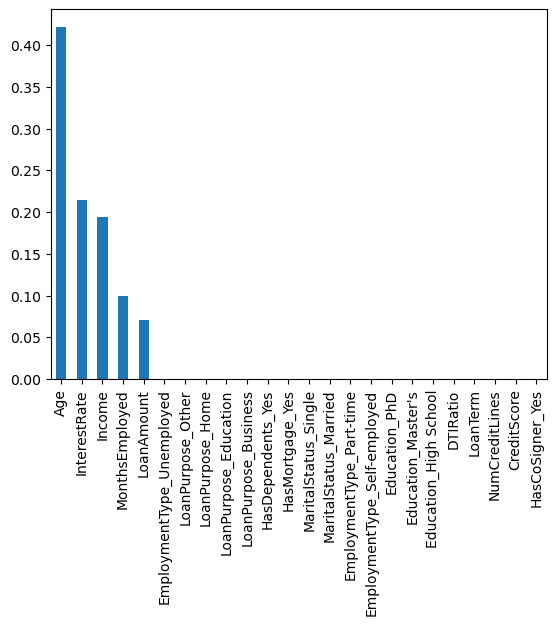

In [64]:
importance = pd.Series(loan_tree.feature_importances_,index=x_train.columns).sort_values(ascending=False)
importance.plot(kind='bar')

The decision tree identified age, interest rate of the loan, income of the customer, number of months customer has been employed and  loan amount as most influential predictors of loan default risk.